# Random Forest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize']=(10,5)
plt.rcParams['figure.dpi']=150
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("glass.csv")
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df=df.dropna(how='all')

In [4]:
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7.0
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7.0
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7.0
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7.0


In [5]:
df.dtypes

RI      float64
Na      float64
Mg      float64
Al      float64
Si      float64
K       float64
Ca      float64
Ba      float64
Fe      float64
Type    float64
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    float64
dtypes: float64(10)
memory usage: 18.4 KB


In [7]:
df.isna().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [8]:
df.duplicated().sum()

1

In [9]:
df[df.duplicated(keep=False)]

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
38,1.52213,14.21,3.82,0.47,71.77,0.11,9.57,0.0,0.0,1.0
39,1.52213,14.21,3.82,0.47,71.77,0.11,9.57,0.0,0.0,1.0


In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

0

In [12]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000
mean,1.518348,13.404085,2.679202,1.449484,72.655070,0.498873,8.954085,0.175869,0.057277,2.788732
std,0.003033,0.816662,1.443691,0.495925,0.773998,0.653185,1.425882,0.498245,0.097589,2.105130
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516520,12.900000,2.090000,1.190000,72.280000,0.130000,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.560000,8.600000,0.000000,0.000000,2.000000
75%,1.519150,13.810000,3.600000,1.630000,73.090000,0.610000,9.150000,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


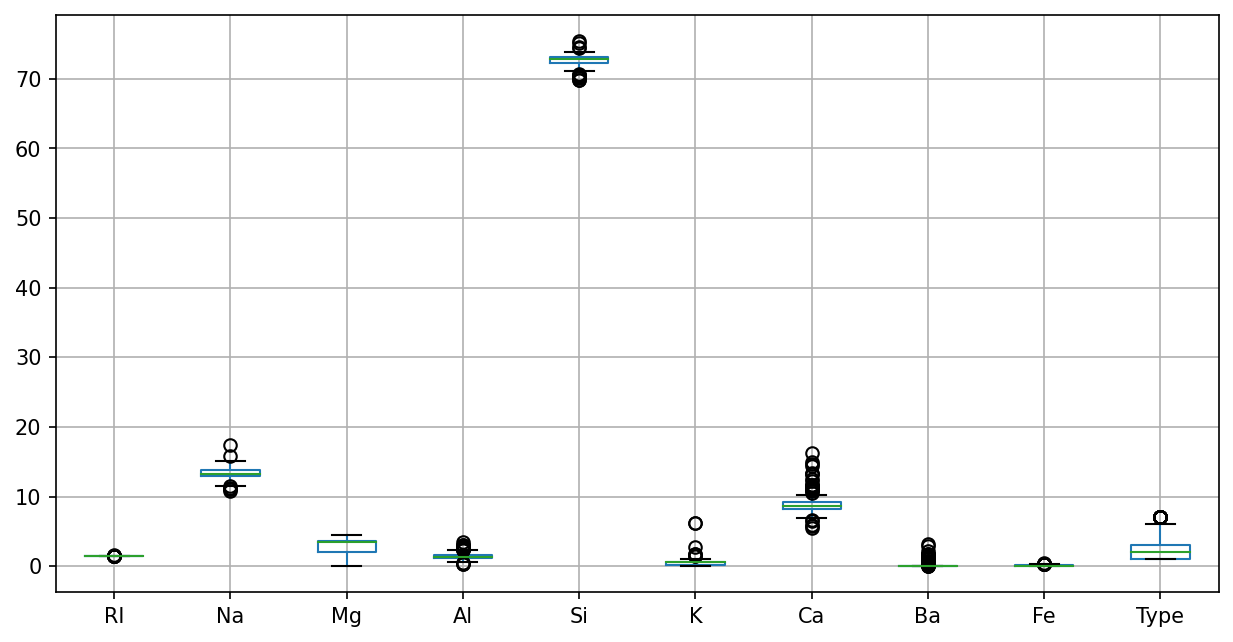

In [13]:
df.boxplot()
plt.show()

# Data Visualization :

<Figure size 1500x750 with 0 Axes>

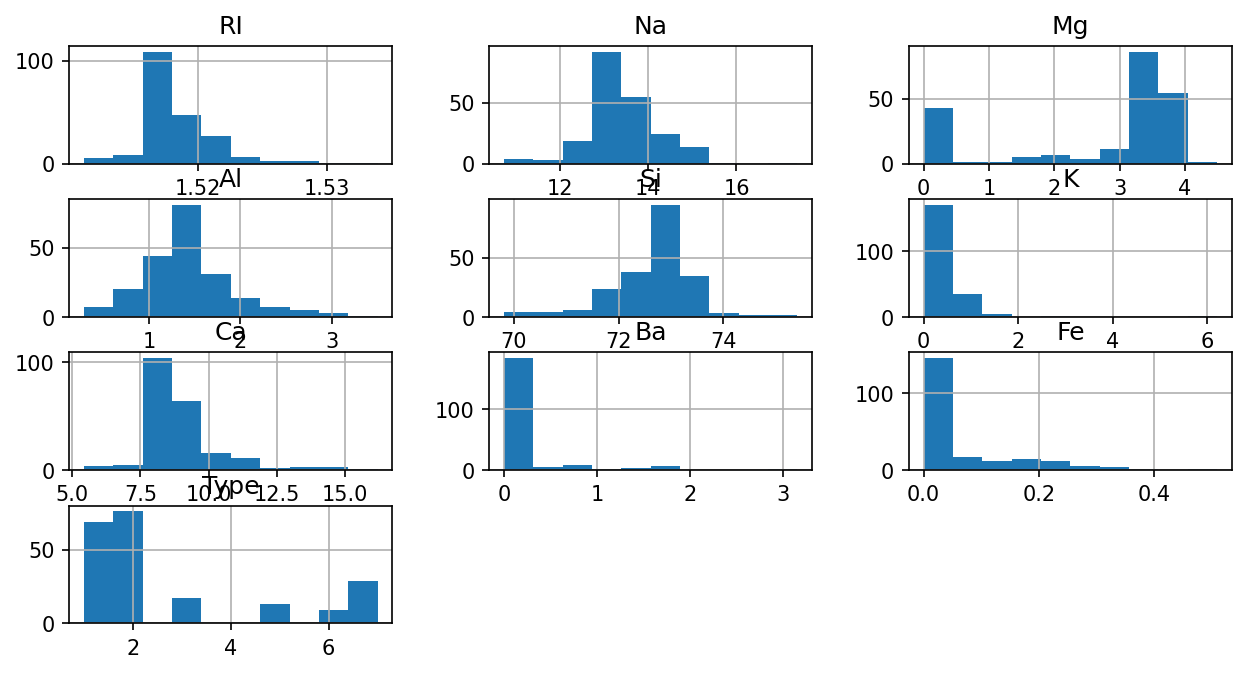

In [14]:
plt.tight_layout()
df.hist()
plt.show()

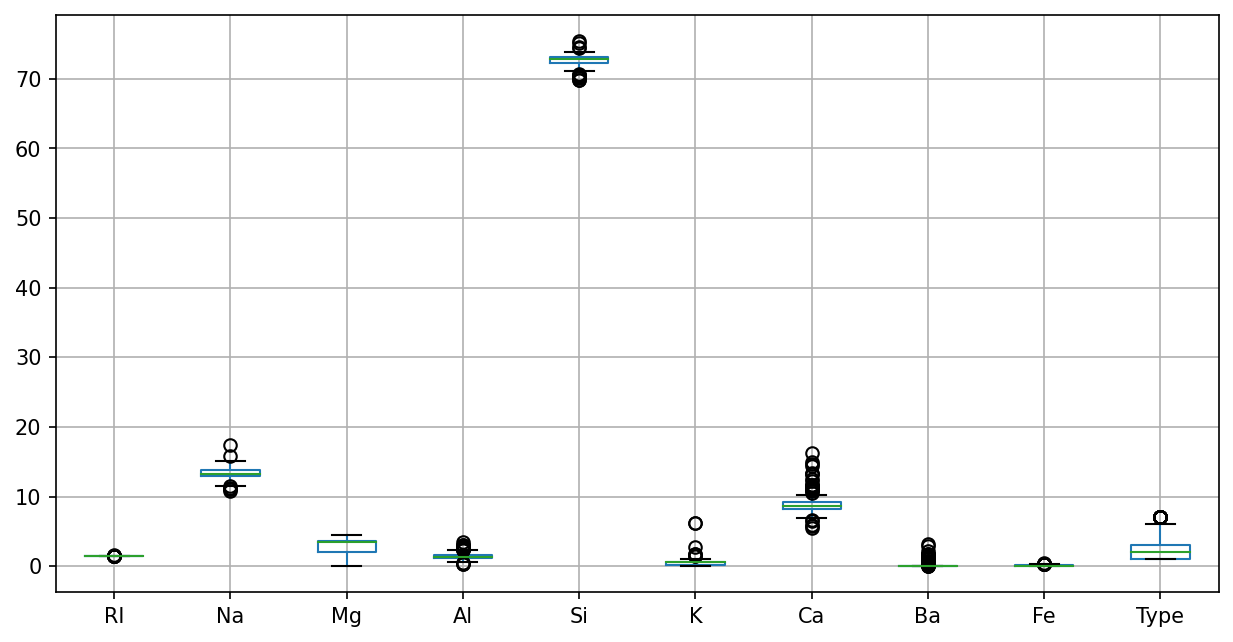

In [15]:
df.boxplot()
plt.show()

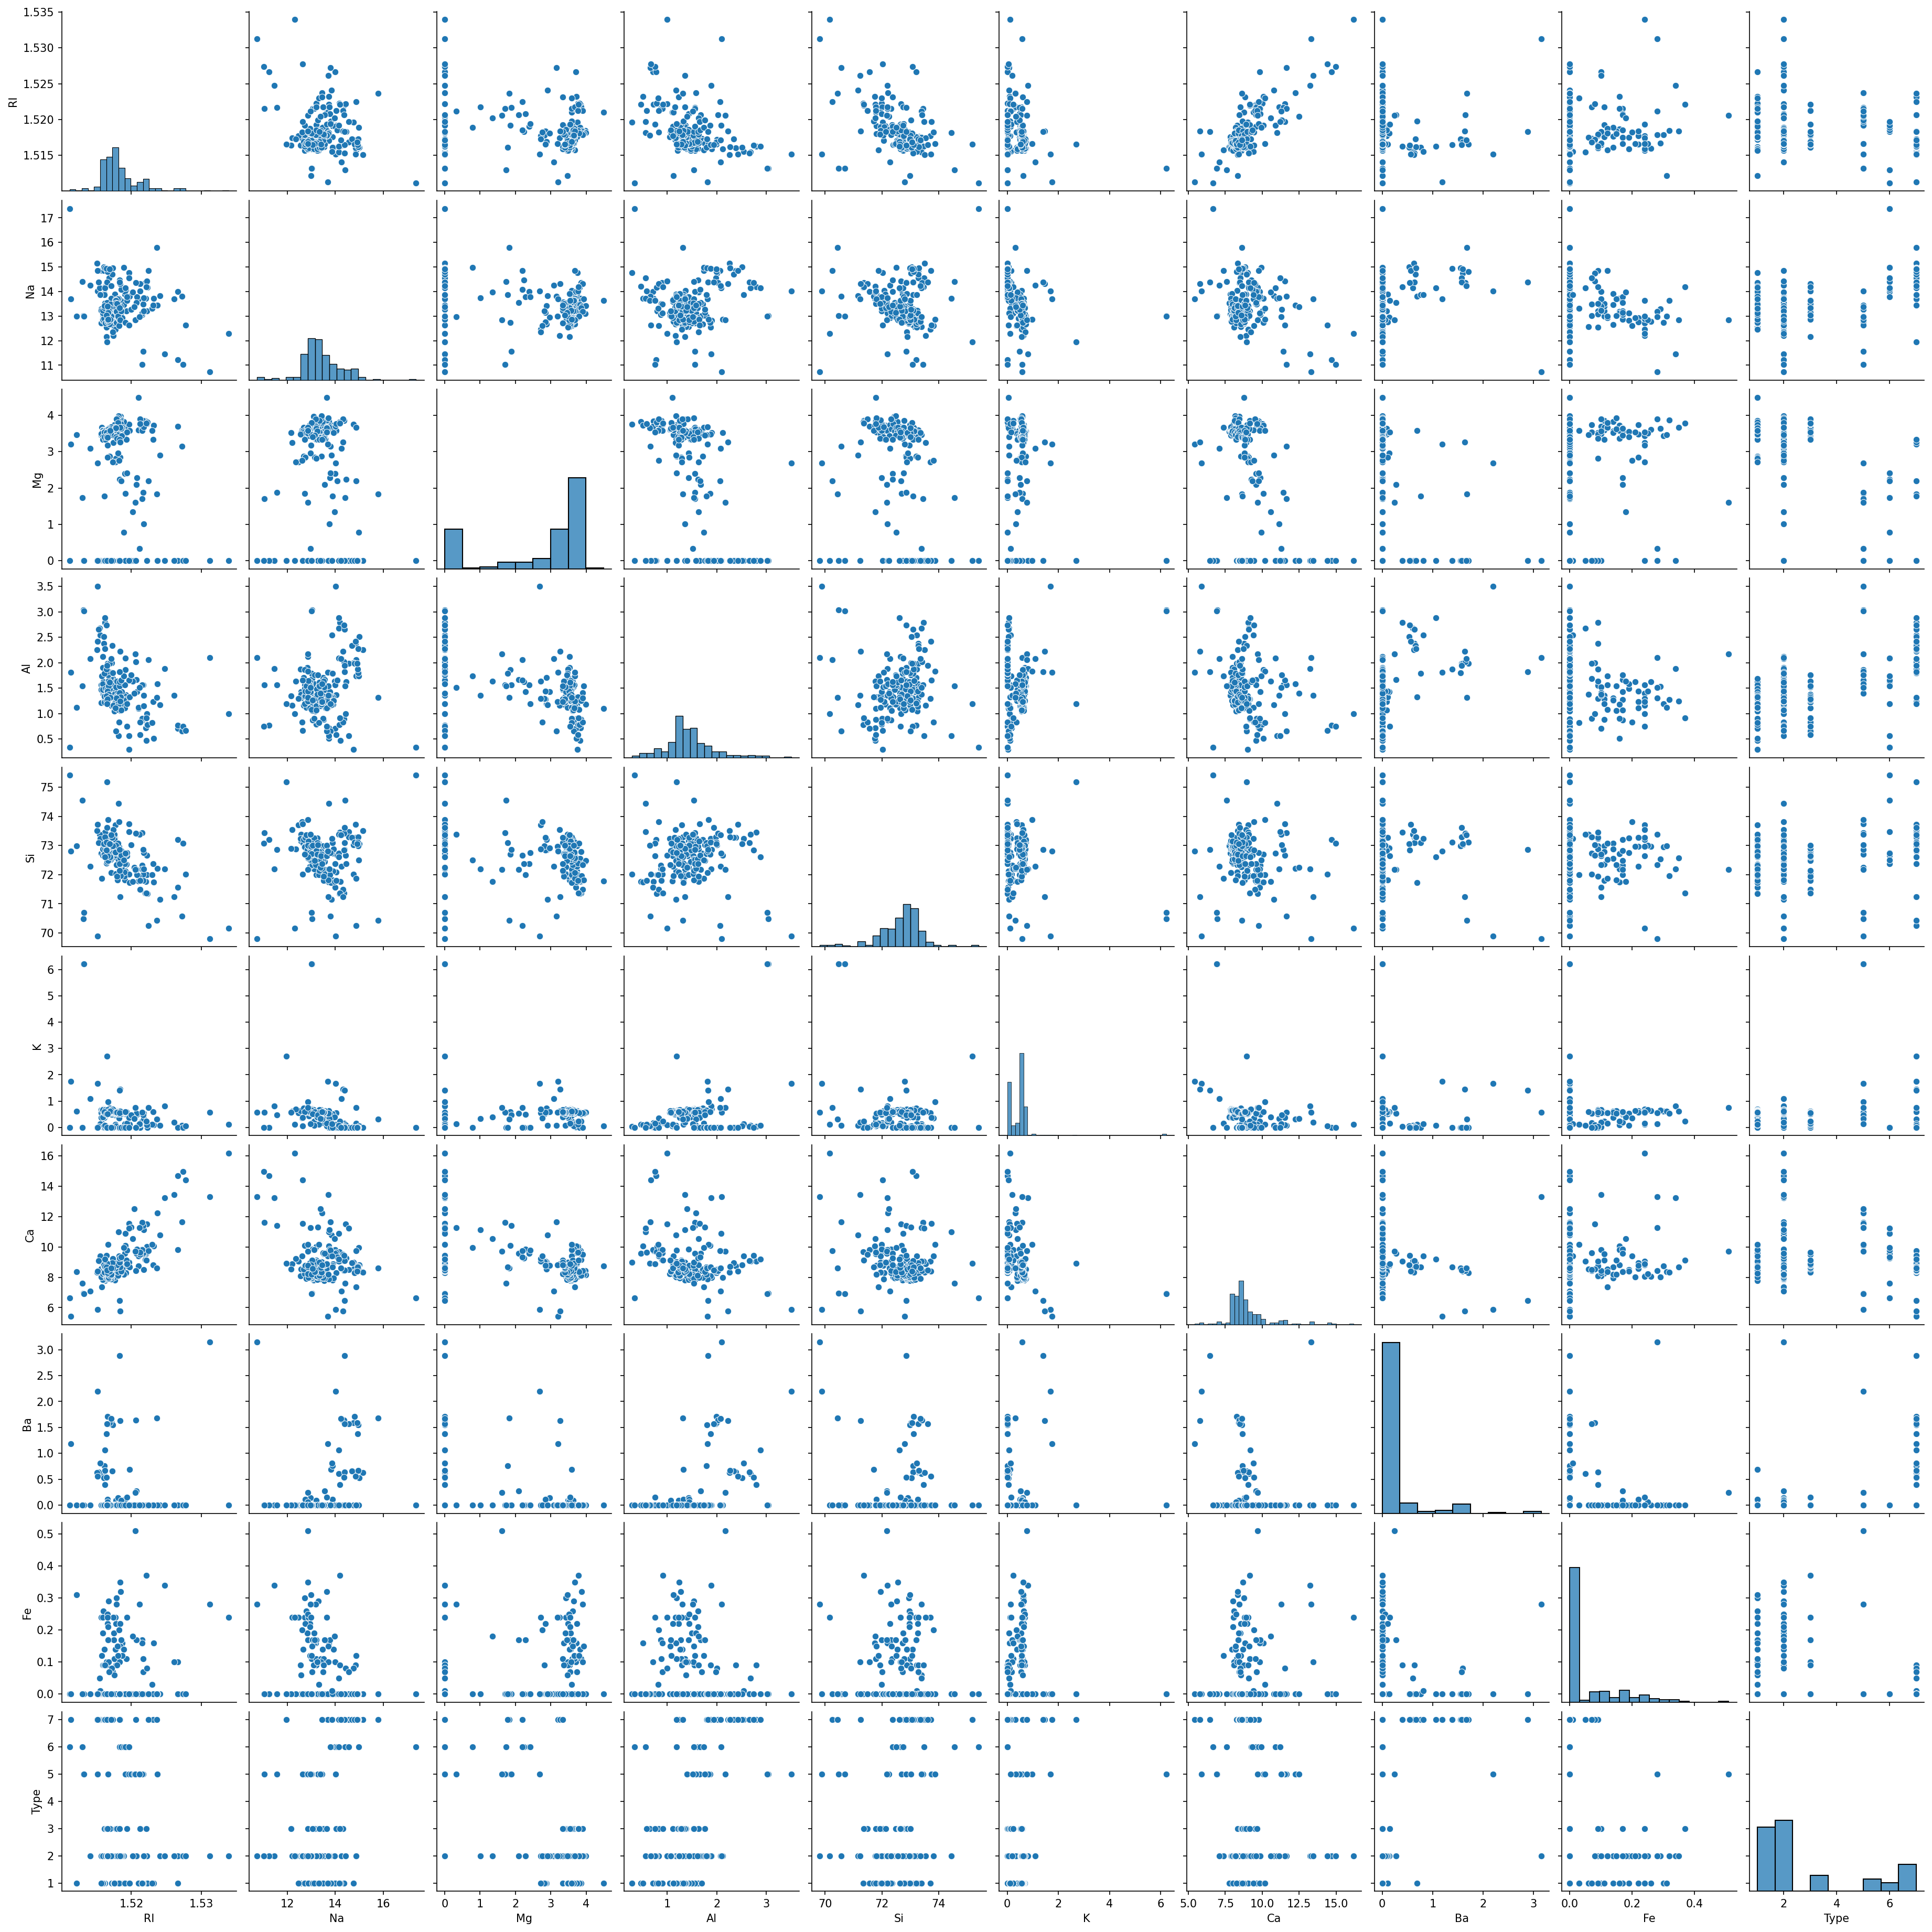

In [16]:
sns.pairplot(df)
plt.show()

In [17]:
df.corr()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
RI,1.000000,-0.198802,-0.127526,-0.400973,-0.539000,-0.287645,0.811183,0.001679,0.147083,-0.160140
Na,-0.198802,1.000000,-0.278420,0.167735,-0.064885,-0.264158,-0.278194,0.329080,-0.239374,0.508837
Mg,-0.127526,-0.278420,1.000000,-0.479575,-0.162437,0.007617,-0.446197,-0.491818,0.085426,-0.744195
Al,-0.400973,0.167735,-0.479575,1.000000,-0.016195,0.323683,-0.258068,0.480642,-0.080583,0.597432
Si,-0.539000,-0.064885,-0.162437,-0.016195,1.000000,-0.197281,-0.207145,-0.104389,-0.097717,0.147725
K,-0.287645,-0.264158,0.007617,0.323683,-0.197281,1.000000,-0.317032,-0.043653,-0.009372,-0.012455
Ca,0.811183,-0.278194,-0.446197,-0.258068,-0.207145,-0.317032,1.000000,-0.112208,0.126314,0.002677
Ba,0.001679,0.329080,-0.491818,0.480642,-0.104389,-0.043653,-0.112208,1.000000,-0.059729,0.574896
Fe,0.147083,-0.239374,0.085426,-0.080583,-0.097717,-0.009372,0.126314,-0.059729,1.000000,-0.191090
Type,-0.160140,0.508837,-0.744195,0.597432,0.147725,-0.012455,0.002677,0.574896,-0.191090,1.000000


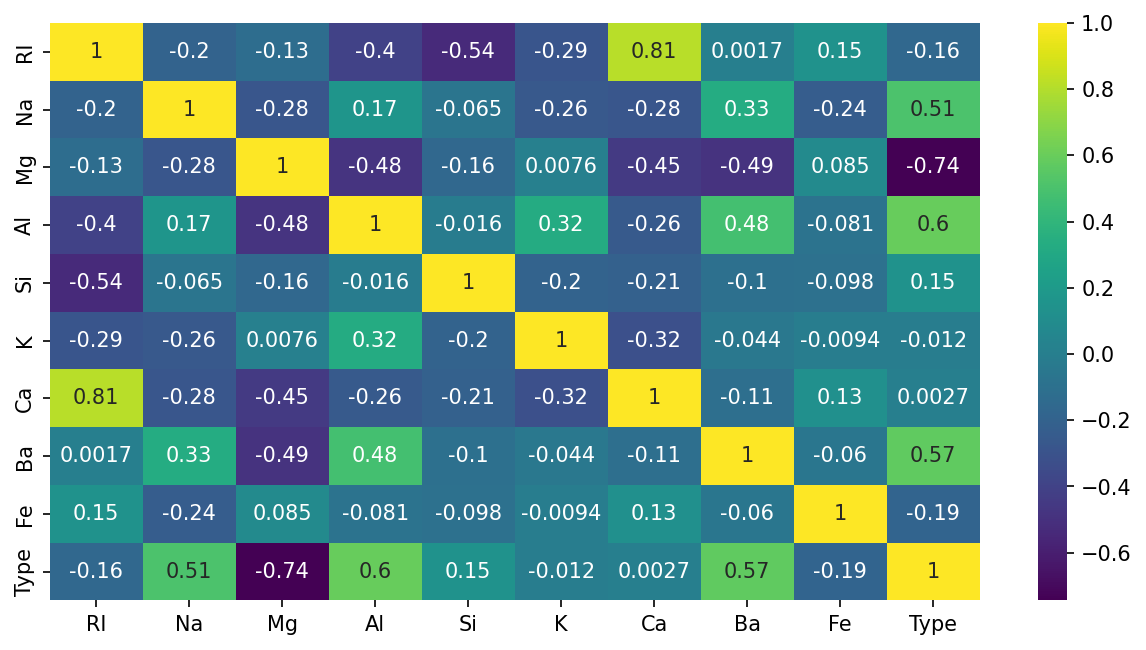

In [18]:
sns.heatmap(df.corr(),annot=True,cmap='viridis')
plt.show()

In [19]:
import statsmodels.formula.api as smf
vif_model=smf.ols('Type~RI+Na+Mg+Al+Si+K+Ca+Ba+Fe',data=df).fit()

In [20]:
vif_model.pvalues

Intercept    0.120630
RI           0.250976
Na           0.121107
Mg           0.674469
Al           0.035668
Si           0.285305
K            0.576694
Ca           0.770330
Ba           0.279176
Fe           0.369920
dtype: float64

In [21]:
#from statsmodels.stats.outliers_influence import variance_inflation_factor

In [22]:
#data=df.drop(columns=['Type'])
#data

In [23]:
# vif=pd.DataFrame()
# vif

In [24]:
# vif['Features']=data.columns
# vif

In [25]:
# vif['VIF']=[variance_inflation_factor(data.values,i) for i in range(len(data.columns))]
# vif

In [26]:
# RI=smf.ols('Type~RI+Na+Mg+Al+K+Ca+Ba+Fe',data=df).fit()
# RI.rsquared,RI.aic

In [27]:
# Si=smf.ols('Type~Si+Na+Mg+Al+K+Ca+Ba+Fe',data=df).fit()

In [28]:
# Si.rsquared,Si.aic

# Data Preprocessing


In [29]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1.0


In [30]:
x=df.iloc[:,0:-1]
y=df['Type']

In [31]:
x

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0
...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0


In [32]:
y

0      1.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
209    7.0
210    7.0
211    7.0
212    7.0
213    7.0
Name: Type, Length: 213, dtype: float64

In [33]:
sc=StandardScaler()
x=sc.fit_transform(x)
x

array([[ 0.87984017,  0.28955813,  1.25723832, ..., -0.14346582,
        -0.35380764, -0.58830108],
       [-0.24381562,  0.59640332,  0.63931074, ..., -0.79020061,
        -0.35380764, -0.58830108],
       [-0.71641202,  0.15454625,  0.6045957 , ..., -0.82534924,
        -0.35380764, -0.58830108],
       ...,
       [ 0.76086485,  1.17327228, -1.86017161, ..., -0.36138732,
         2.94550057, -0.58830108],
       [-0.60735132,  1.19781989, -1.86017161, ..., -0.33326842,
         2.80467644, -0.58830108],
       [-0.40905912,  1.01371278, -1.86017161, ..., -0.23485225,
         3.00585377, -0.58830108]])

#  Random Forest Model Implementation


In [34]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [35]:
model=RandomForestClassifier(n_estimators=100,max_features=4)
model.fit(xtrain,ytrain)

RandomForestClassifier(max_features=4)

In [36]:
y_pred=model.predict(xtest)
y_pred

array([1., 7., 1., 7., 2., 2., 1., 2., 2., 2., 2., 2., 1., 2., 6., 5., 7.,
       1., 1., 7., 2., 7., 7., 7., 2., 5., 1., 1., 6., 1., 1., 2., 3., 2.,
       2., 7., 2., 3., 2., 2., 1., 2., 1.])

In [37]:
confusion_matrix(ytest,y_pred)

array([[10,  0,  0,  0,  0,  0],
       [ 2, 12,  0,  1,  0,  0],
       [ 0,  1,  2,  0,  0,  0],
       [ 0,  2,  0,  1,  0,  0],
       [ 0,  1,  0,  0,  2,  0],
       [ 0,  1,  0,  0,  0,  8]], dtype=int64)

In [38]:
((10+10+2+3+2+7)/(10+4+10+1+1+2+3+1+2+2+7)*100)

79.06976744186046

In [39]:
print(classification_report(ytest,y_pred))

              precision    recall  f1-score   support

         1.0       0.83      1.00      0.91        10
         2.0       0.71      0.80      0.75        15
         3.0       1.00      0.67      0.80         3
         5.0       0.50      0.33      0.40         3
         6.0       1.00      0.67      0.80         3
         7.0       1.00      0.89      0.94         9

    accuracy                           0.81        43
   macro avg       0.84      0.73      0.77        43
weighted avg       0.82      0.81      0.81        43



In [40]:
print("Training Accuracy:",model.score(xtrain,ytrain))
print("Testing Accuracy:",model.score(xtest,ytest))

Training Accuracy: 1.0
Testing Accuracy: 0.813953488372093


# Hyperparameter tunning

In [41]:
final_model=RandomForestClassifier()

In [42]:
params={
    'max_features':[2,3,4,5,6]
}
params

{'max_features': [2, 3, 4, 5, 6]}

In [43]:
grid=GridSearchCV(estimator=final_model,param_grid=params,verbose=1)

In [44]:
grid.fit(xtrain,ytrain)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'max_features': [2, 3, 4, 5, 6]}, verbose=1)

In [45]:
grid.best_params_

{'max_features': 2}

In [46]:
final_model=RandomForestClassifier(n_estimators=100,max_features=2)

In [47]:
final_model.fit(xtrain,ytrain)

RandomForestClassifier(max_features=2)

In [48]:
ypred=final_model.predict(xtest)

In [49]:
confusion_matrix(ytest,ypred)

array([[ 9,  1,  0,  0,  0,  0],
       [ 2, 12,  0,  1,  0,  0],
       [ 1,  0,  2,  0,  0,  0],
       [ 0,  0,  0,  3,  0,  0],
       [ 0,  1,  0,  0,  2,  0],
       [ 0,  2,  0,  0,  0,  7]], dtype=int64)

In [50]:
((10+11+2+1+2+8)/(10+3+11+1+1+2+2+1+1+2+1+8)*100)

79.06976744186046

In [51]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

         1.0       0.75      0.90      0.82        10
         2.0       0.75      0.80      0.77        15
         3.0       1.00      0.67      0.80         3
         5.0       0.75      1.00      0.86         3
         6.0       1.00      0.67      0.80         3
         7.0       1.00      0.78      0.88         9

    accuracy                           0.81        43
   macro avg       0.88      0.80      0.82        43
weighted avg       0.84      0.81      0.81        43



In [52]:
print("Training Accuracy:",final_model.score(xtrain,ytrain))
print("Testing Accuracy:",final_model.score(xtest,ytest))

Training Accuracy: 1.0
Testing Accuracy: 0.813953488372093


#  Bagging

In [53]:
from sklearn.tree import DecisionTreeClassifier

In [54]:
bag=BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=100,random_state=42)


In [55]:
bag.fit(xtrain,ytrain)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100,
                  random_state=42)

In [56]:
bag_pred=bag.predict(xtest)
bag_pred

array([1., 7., 1., 7., 1., 2., 1., 2., 2., 1., 2., 5., 1., 2., 6., 5., 7.,
       1., 1., 7., 1., 7., 7., 7., 3., 5., 1., 1., 6., 1., 1., 2., 3., 2.,
       2., 7., 5., 3., 2., 2., 1., 2., 7.])

In [57]:
confusion_matrix(ytest,bag_pred)

array([[9, 0, 0, 0, 0, 1],
       [5, 9, 0, 1, 0, 0],
       [0, 0, 3, 0, 0, 0],
       [0, 0, 0, 3, 0, 0],
       [0, 1, 0, 0, 2, 0],
       [0, 1, 0, 0, 0, 8]], dtype=int64)

In [58]:
print(classification_report(ytest,bag_pred))

              precision    recall  f1-score   support

         1.0       0.64      0.90      0.75        10
         2.0       0.82      0.60      0.69        15
         3.0       1.00      1.00      1.00         3
         5.0       0.75      1.00      0.86         3
         6.0       1.00      0.67      0.80         3
         7.0       0.89      0.89      0.89         9

    accuracy                           0.79        43
   macro avg       0.85      0.84      0.83        43
weighted avg       0.81      0.79      0.79        43



In [59]:
print("Training Accuracy of Bagging Algorithm:",bag.score(xtrain,ytrain))
print("Testing Accuracy of Bagging Algorithm:",bag.score(xtest,ytest))

Training Accuracy of Bagging Algorithm: 1.0
Testing Accuracy of Bagging Algorithm: 0.7906976744186046


# Boosting

In [60]:
boost=AdaBoostClassifier(
    n_estimators=100,random_state=42)

In [61]:
boost.fit(xtrain,ytrain)

AdaBoostClassifier(n_estimators=100, random_state=42)

In [62]:
boost_pred=boost.predict(xtest)
boost

AdaBoostClassifier(n_estimators=100, random_state=42)

In [63]:
confusion_matrix(ytest,boost_pred)

array([[ 9,  0,  0,  0,  0,  1],
       [13,  2,  0,  0,  0,  0],
       [ 3,  0,  0,  0,  0,  0],
       [ 0,  1,  0,  2,  0,  0],
       [ 0,  3,  0,  0,  0,  0],
       [ 0,  3,  0,  1,  0,  5]], dtype=int64)

In [64]:
print(classification_report(ytest,boost_pred))

              precision    recall  f1-score   support

         1.0       0.36      0.90      0.51        10
         2.0       0.22      0.13      0.17        15
         3.0       0.00      0.00      0.00         3
         5.0       0.67      0.67      0.67         3
         6.0       0.00      0.00      0.00         3
         7.0       0.83      0.56      0.67         9

    accuracy                           0.42        43
   macro avg       0.35      0.38      0.34        43
weighted avg       0.38      0.42      0.36        43



In [65]:
print("Training Accuracy of Boosting Algorithm:",boost.score(xtrain,ytrain))
print("Testing Accuracy of Boosting Algorithm:",boost.score(xtest,ytest))

Training Accuracy of Boosting Algorithm: 0.4235294117647059
Testing Accuracy of Boosting Algorithm: 0.4186046511627907


# comparison

In [66]:

print("Training Accuracy:",final_model.score(xtrain,ytrain))
print("Testing Accuracy:",final_model.score(xtest,ytest))

Training Accuracy: 1.0
Testing Accuracy: 0.813953488372093


In [67]:
print("Training Accuracy of Bagging Algorithm:",bag.score(xtrain,ytrain))
print("Testing Accuracy of Bagging Algorithm:",bag.score(xtest,ytest))

Training Accuracy of Bagging Algorithm: 1.0
Testing Accuracy of Bagging Algorithm: 0.7906976744186046


In [68]:
print("Training Accuracy of Boosting Algorithm:",boost.score(xtrain,ytrain))
print("Testing Accuracy of Boosting Algorithm:",boost.score(xtest,ytest))

Training Accuracy of Boosting Algorithm: 0.4235294117647059
Testing Accuracy of Boosting Algorithm: 0.4186046511627907


# Notes